# ArcGIS Python API

The ArcGIS API for Python is a powerful, modern and easy to use Pythonic library to perform GIS visualization and analysis, spatial data management and GIS system administration tasks that can run both in an interactive fashion, as well as using scripts.

# Data Preparation

The Hoston Police department shares historical crime statistics at http://www.houstontx.gov/police/cs/crime-stats-archives.htm that we'll be using for our analysis.
<img src="hpd.png" width="750"/>

## Fetch data

In [ ]:
import pandas as pd
import calendar

combined_df = pd.DataFrame()

for year in range(10, 17):
    for month in range(1, 13):
        url = 'http://www.houstontx.gov/police/cs/xls/{0}{1}.xls'.format(calendar.month_name[month].lower()[:3], year)
        df = pd.read_excel(url)
        combined_df = combined_df.append(df, ignore_index=True)

In [ ]:
# archive the data so we don't need to re-fetch it:
combined_df.to_csv(r'C:\xc\Presentations\Demos\Houston\crime_df.csv', index=False)

## Data cleanup

In [25]:
import pandas as pd

crimes_df = pd.read_csv(r'C:\xc\Presentations\Demos\Houston\crime_df.csv', parse_dates=[7], low_memory=False)

In [26]:
crimes_df.head(3)

,# Of,# Of Offenses,# Offenses,# offenses,Beat,Block Range,BlockRange,Date,Field11,Hour,Offense Type,Premise,Street Name,StreetName,Suffix,Type,Unnamed: 1
0,NaN,1.0,NaN,NaN,11H30,3000-3099,NaN,2010-01-08,NaN,22.0,Murder,20R,BROADWAY,NaN,-,ST,NaN
1,NaN,1.0,NaN,NaN,10H50,2800-2899,NaN,2010-01-17,NaN,18.0,Murder,18C,MCGOWEN,NaN,-,ST,NaN
2,NaN,1.0,NaN,NaN,15E30,9600-9699,NaN,2010-01-01,NaN,0.0,Murder,18A,MARLIVE,NaN,-,LN,NaN


### Data wrangling

In [102]:
# drop empty rows and replace '-' with ''
crimes_df.dropna(axis=0, how='all', inplace=True)
crimes_df = crimes_df.replace('-', '')

# offenses are spread across four columns with different name. Similar for BlockRange and StreetName. Combine the columns:
crimes_df['Offenses'] = (crimes_df['# Of'].combine_first( \
                         crimes_df['# Of Offenses']).combine_first( \
                         crimes_df['# Offenses']).combine_first( \
                         crimes_df['# offenses'])).astype(int)

crimes_df['BlockRange'] = crimes_df['BlockRange'].combine_first( \
                          crimes_df['Block Range'])

crimes_df['StreetName'] = crimes_df['StreetName'].combine_first( \
                          crimes_df['Street Name'])

# extract the approximate (mid) address from the block range 
# and construct an address column using it and the street suffix, name and type:
houseno = crimes_df.BlockRange.str.extract('(?P<start_addr>\d+)-(?P<end_addr>\d+)', expand=False)
crimes_df['HouseNo'] = (houseno.start_addr.astype(float) + houseno.end_addr.astype(float) + 1.0) / 2
crimes_df['HouseNo'] = crimes_df['HouseNo'].fillna(50.0)

crimes_df['Address'] = crimes_df.HouseNo.astype(int).map(str) + ' ' + \
                       crimes_df.Suffix.map(str) + ' ' + \
                       crimes_df.StreetName.map(str) + ' ' + \
                       crimes_df.Type.map(str) + ', Houston, TX'
            
# the hour column contains strings (with leading quotes), floats and int as well as empty strings. Convert them all to ints:
crimes_df['Hour'] = crimes_df['Hour'].apply(lambda x : int(float(x.replace("'", ""))) if type(x) == str else int(float(x)))

# create a new column for Day of the week, useful for analysis:
crimes_df['DayOfWeek'] = crimes_df.Date.dt.weekday_name

# rename Offense Type to Category
crimes_df = crimes_df.rename(columns={'Offense Type' : 'Category'})

### Cleaned up data

<font color='#999999'>

</font>

In [108]:
analysis_df = crimes_df[['Date', 'Hour', 'DayOfWeek', 'Category', 'Offenses', 'Beat', 'Address']]
analysis_df.head()

,Date,Hour,DayOfWeek,Category,Offenses,Beat,Address
0,2010-01-08,22,Friday,Murder,1,11H30,"3050 BROADWAY ST, Houston, TX"
1,2010-01-17,18,Sunday,Murder,1,10H50,"2850 MCGOWEN ST, Houston, TX"
2,2010-01-01,0,Friday,Murder,1,15E30,"9650 MARLIVE LN, Houston, TX"
3,2010-01-09,14,Saturday,Murder,1,5F20,"9050 LONG POINT RD, Houston, TX"
4,2010-01-18,14,Monday,Murder,1,10H40,"4350 GARROTT ST, Houston, TX"


In [109]:
houston_processed = r'C:\xc\Presentations\Demos\Houston\houston_processed.csv'
analysis_df.to_csv(houston_processed, index_label='id')

## Geocoding

In [139]:
portal = GIS('http://dev004049.esri.com/portal/home', USERNAME, PASSWORD)

gcd = portal.content.search('GeocodingTools')[0]
gcd

<Item title:"GeocodingTools" type:Geoprocessing Service owner:admin>

In [ ]:
from arcgis.geoprocessing import import_toolbox
gcdtools = import_toolbox(gcd)

In [ ]:
portal.content.add({}, houston_processed)
houston_item = portal.content.search('houston_processed.csv')[0]

In [ ]:
url = 'http://dev004049.esri.com/portal/sharing/servers/7359d5db3bb14ddabcea4c8e66b3486c/rest/services/World/GeocodeServer'

geocode_parameters = gcdtools.analyze_geocode_input(url,'', {'itemid' : houston_item.itemid},
                              ','.join(list(analysis_df.columns)),
                              {"fileType": "csv", "headerRowExists": "true","columnDelimiter":"", "textQualifier":""}, '', '')

geocode_result = gcdtools.batch_geocode(geocode_parameters, url, 'csv', '', 
                                        {'itemid' : houston_item.itemid}, 'US', 
                                        '', "x,y", 1, 
                                        {"serviceProperties" : {"name" : "houston_geocoded"}}, 
                                        {"outSR": {"wkid": 4326}} )

In [ ]:
geocoded_crime = portal.content.get(geocode_result['itemId'])
geocoded_csv = geocoded_crime.get_data()

In [135]:
df = pd.read_csv(geocoded_csv, index_col=0)
df.head()

,Date,Hour,DayOfWeek,Category,Offenses,Beat,Address,X,Y
id,,,,,,,,,
1000,2010-01-12,16,Tuesday,Aggravated Assault,1,14D30,"5850 OVERDALE , Houston, TX",-95.329910,29.657022
1020,2010-01-10,17,Sunday,Aggravated Assault,1,19G40,"8650 RICHARD ARMS CIR, Houston, TX",-95.576367,29.683702
1030,2010-01-04,22,Monday,Aggravated Assault,1,18F60,"7950 BELLAIRE BLVD, Houston, TX",-95.526159,29.705268
1021,2010-01-07,8,Thursday,Aggravated Assault,1,3B50,"50 DE BOLL ST, Houston, TX",-95.380070,29.842693
1008,2010-01-30,6,Saturday,Aggravated Assault,1,5F20,"7950 LONG POINT RD, Houston, TX",-95.486725,29.802886


## Spatially Enabled Dataframe

Spatial Dataframes let you work with spatial data as if it were a Pandas dataframe. It adds geospatial operations to Pandas as well as the ability to read and write shapefiles and file geodatabases.

In [1]:
from arcgis.features import GeoAccessor, GeoSeriesAccessor

In [ ]:
geoms = []
for i in range(0, len(df)):
    loc = df.iloc[i]
    geoms.append(arcgis.geometry.Point(loc.X, loc.Y))

In [ ]:
spdf = df.copy()
spdf['SHAPE'] = geoms
spdf.spatial.set_geometry("SHAPE")
spdf.sr = 4326

## Pandas Dataframe to shapefiles or file geodatabase

In [ ]:
import os

for year in range(2010, 2017):
    start_date = str(year) + '-01-01'
    end_date = str(year) + '-12-31'
    
    mask = (spdf['Date'] > start_date) & (spdf['Date'] <= end_date)
    spdf_year = spdf.loc[mask]
    
    directory = r'C:\xc\Presentations\Demos\Houston\houstoncrime' + str(year) 
    if not os.path.exists(directory):
        os.makedirs(directory)
        
    spdf_year.to_featureclass(out_location=directory,
                              out_name='Houston' + str(year) + '.shp')

In [ ]:
spdf.to_featureclass(out_location=r"C:\xc\Presentations\Demos\Houston\houston.gdb", out_name="crime")

## Connect the data to your GIS

In [12]:
from arcgis.gis import GIS

gis = GIS('https://dev003246.esri.com/portal', USERNAME, PASSWORD)

#### Publish as hosted feature layer

In [ ]:
data = r'C:\xc\Presentations\Demos\Houston\shp\houston2016.zip' 
shpfile = gis.content.add({}, data)

In [ ]:
crime2016 = shpfile.publish()

In [199]:
crime2016 = gis.content.search('houston2016', 'feature layer')[0]
crime2016

<Item title:"houston2016" type:Feature Service owner:admin>

#### Attach to geoanalytics datastore as bigdata file share

In [ ]:
datastores = arcgis.geoanalytics.get_datastores()

In [ ]:
houston_bigdata = datastores.add_bigdata('Houston_crime', r'\\teton\atma_shared\datasets\Houstonshp')

In [ ]:
houston_yearly_bigdata = datastores.add_bigdata('Houston_crime_yearly', r'\\teton\atma_shared\datasets\HoustonCrime')

The datasets within the attached bigdata fileshare show up as Items and Layers and are available for analysis:

In [365]:
items = gis.content.search("houston", "big data file share")
for item in items:
    display(item)

<Item title:"bigDataFileShares_Houston_crime" type:Big Data File Share owner:admin>

<Item title:"bigDataFileShares_Houston_crime_yearly" type:Big Data File Share owner:admin>

In [366]:
houston_crime = items[0]
houston_yearly = items[1]

In [367]:
houston_yearly.layers

[<Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2010">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2011">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2012">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2013">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2014">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataStoreCatalogs/bigDataFileShares_Houston_crime_yearly/BigDataCatalogServer/houstoncrime2015">,
 <Layer url:"https://dev003247.esri.com/gax/rest/services/DataSt

# Mapping, Visualization and Analysis

Visualize crime layer using the Map widget and Smart Mapping:

In [14]:
houston = arcgis.geocoding.geocode('Houston, TX')[0]

In [27]:
crime2016 = gis.content.search('houston2016', 'feature layer')[0]

map1 = gis.map(houston, 12)
map1.add_layer(crime2016)

map2 = gis.map(houston, 12)
map2.add_layer(crime2016, {"renderer":"HeatmapRenderer", "opacity":0.75})

from ipywidgets import *

map1.layout=Layout(flex='1 1', padding='10px')
map2.layout=Layout(flex='1 1', padding='10px')

crimebox = HBox([map1, map2])
crimebox

## Exploratory data analysis

In [1]:
from arcgis.features import GeoAccessor, GeoSeriesAccessor
df = pd.DataFrame.spatial.from_featureclass(location=r"C:\xc\Presentations\GeoPython\Houston\shp\Houston2015.shp")

What are the most comon crimes?

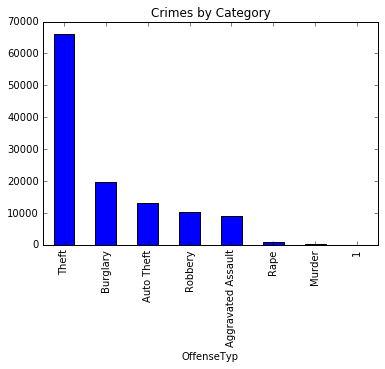

In [28]:
# crimes by category

%matplotlib inline
import matplotlib.pyplot as plt

groups = df.groupby("OffenseTyp")["OffenseTyp"].count()
groups = groups.sort_values(ascending=0)
plt.figure()
groups.plot(kind='bar', title="Crimes by Category")

Does crime distribution change by the day of the week?

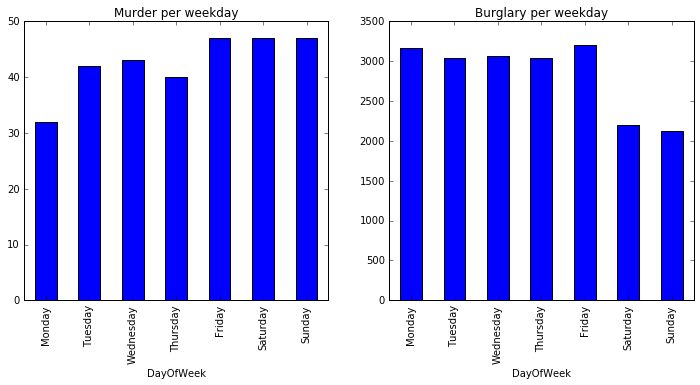

In [29]:
fig, axs = plt.subplots(1,2)

weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_murder = df[df.OffenseTyp == "Murder"]
gr_murder = df_murder.groupby("DayOfWeek")["Offenses"].sum()
gr_murder = gr_murder[weekdays]

df_burglary = df[df.OffenseTyp == "Burglary"]
gr_burglary = df_burglary.groupby("DayOfWeek")["Offenses"].sum()
gr_burglary = gr_burglary[weekdays]

gr_murder.plot(kind="bar", title="Murder per weekday", ax=axs[0])
gr_burglary.plot(kind="bar", title="Burglary per weekday", ax=axs[1], figsize=(12, 5))

Which crimes occur during which part of the day?

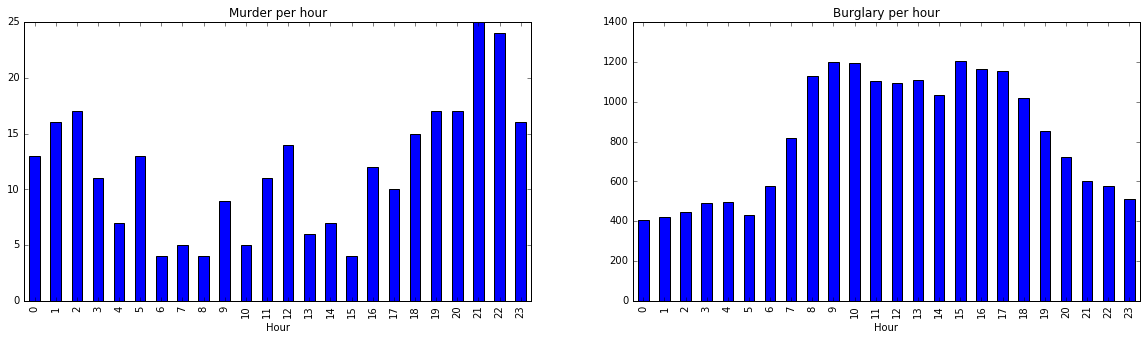

In [30]:
# thefts and burglaries by hour
fig, axs = plt.subplots(1,2)
hours = [x for x in range(24)]
df_theft = df[df.OffenseTyp == "Murder"]
gr_theft = df_theft.groupby("Hour")["OffenseTyp"].count()
gr_theft = gr_theft[hours]

df_burglary = df[df.OffenseTyp == "Burglary"]
gr_burglary = df_burglary.groupby("Hour")["OffenseTyp"].count()
gr_burglary = gr_burglary[hours]

gr_theft.plot(kind="bar", title="Murder per hour", ax=axs[0])
gr_burglary.plot(kind="bar", title="Burglary per hour", ax=axs[1], figsize=(20, 5))

## Big data analytics

GeoAnalytics provides a set of powerful tools for performing spatial analysis on big data. GeoAnalytics Tools are powered by your ArcGIS GeoAnalytics Server. ArcGIS GeoAnalytics Server distributes the analysis between multiple server nodes. By using distributed processing, you can process large datasets in less time.

### Find hot spots of crime

The “Find Hot Spots” tool can be used to identify statistically significant clusters of crime.

We can automate the creation of hotspots for all crime categories, across the years and create persisted information products in the form of web layers:

In [209]:
from arcgis.geoanalytics.analyze_patterns import find_hot_spots
arcgis.env.process_spatial_reference=32611
arcgis.env.verbose = False

In [260]:
for category in df.Category.unique()[:-1]:
    lyrid = 0
    for year in range(2010, 2017):
        output_name='Houston_' + category.replace(' ', '_') + '_Hotspot_' + str(year)
        print('Generating ' + output_name)
        layer = houston_yearly.layers[lyrid]
        layer.filter = "Category='{}'".format(category)
        
        find_hot_spots(layer, bin_size=0.5, bin_size_unit='Miles', 
                       neighborhood_distance=1, neighborhood_distance_unit='Miles', output_name=output_name)
        
        lyrid = lyrid + 1

Generating Houston_Aggravated_Assault_Hotspot_2010
Generating Houston_Aggravated_Assault_Hotspot_2011
Generating Houston_Aggravated_Assault_Hotspot_2012
Generating Houston_Aggravated_Assault_Hotspot_2013
Generating Houston_Aggravated_Assault_Hotspot_2014
Generating Houston_Aggravated_Assault_Hotspot_2015
Generating Houston_Aggravated_Assault_Hotspot_2016
Generating Houston_Burglary_Hotspot_2010
Generating Houston_Burglary_Hotspot_2011
Generating Houston_Burglary_Hotspot_2012
Generating Houston_Burglary_Hotspot_2013
Generating Houston_Burglary_Hotspot_2014
Generating Houston_Burglary_Hotspot_2015
Generating Houston_Burglary_Hotspot_2016
Generating Houston_Murder_Hotspot_2010
Generating Houston_Murder_Hotspot_2011
Generating Houston_Murder_Hotspot_2012
Generating Houston_Murder_Hotspot_2013
Generating Houston_Murder_Hotspot_2014
Generating Houston_Murder_Hotspot_2015
Generating Houston_Murder_Hotspot_2016
Generating Houston_Rape_Hotspot_2010
Generating Houston_Rape_Hotspot_2011
Generatin

##### Compare Burglary hot spots with Auto-theft hot spots

In [31]:
hotmap1 = gis.map(houston, 10)
hotmap1.add_layer(gis.content.search('Houston_Burglary_Hotspot_2016')[0])
hotmap2 = gis.map(houston, 10)
hotmap2.add_layer(gis.content.search('Houston_Auto_Theft_Hotspot_2016')[0])

hotmap1.layout=Layout(flex='1 1', padding='3px')
hotmap2.layout=Layout(flex='1 1', padding='3px')

items_layout = Layout(flex='1 1 auto', width='auto')

display(HBox([hotmap1, hotmap2]))
display(HBox(children=[Button(description='Burglary hot spots in 2016', layout=items_layout, button_style='danger'),
                       Button(description='Auto theft hot spots in 2016', layout=items_layout, button_style='danger')],
             layout=Layout(width='100%')))

##### Compare hot spots over time

In [32]:
maps = []
labels = []
items_layout = Layout(flex='1 1 auto', width='auto')
for year in range(2014, 2017):
    layer = gis.content.search('Houston_Auto_Theft_Hotspot_'+str(year))[0]
    hotspotmap = gis.map(houston)
    hotspotmap.add_layer(layer)
    hotspotmap.layout=Layout(flex='1 1', padding='3px')
    maps.append(hotspotmap)
    hotspotmap.basemap='gray'
    labels.append(Button(description='Auto theft hot spots in ' + str(year), layout=items_layout, button_style='danger'))
    
layout=Layout(height='300px')
display(HBox([maps[0], maps[1], maps[2]], layout=layout))
display(HBox(children=labels, layout=Layout(width='100%')))

The hot spots in each category are strikingly similar across years. The hot spots of yesterday are the hotspots of tomorrow, and this information can be used to deploy officers and to identify areas in need of intervention.